# Brain Tumor Classification Pipeline

This notebook reproduces **all** experimental results and figures. It is fully
self-contained: the dataset is downloaded directly from Zenodo at the following link:

https://zenodo.org/records/17447727


No external
storage (e.g. Google Drive) is required, the pipeline is portable and you can run it through this ipynb file.

## 1 — Environment Setup

In [ ]:
# Install required libraries (quiet mode for clean logs)
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy tqdm rarfile

In [ ]:
# ============================================================
# Standard and scientific libraries
# ============================================================
import os
import time
import json
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

# Machine-learning utilities
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.model_selection import StratifiedKFold

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ============================================================
# Global experiment configuration (Table 3)
# ============================================================
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 60
NUM_CLASSES  = 4
INIT_LR      = 0.001

print("Environment ready.")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    print(f"GPU name: {tf.config.list_physical_devices('GPU')[0].name}")

Environment ready.
TensorFlow version: 2.19.0
GPU available: True
GPU name: /physical_device:GPU:0


## 2 — Dataset Download & Extraction

In [ ]:
def download_file(url, filename):
    """Download a file with a progress bar and basic validation."""
    response = requests.get(url, stream=True)
    content_type = response.headers.get('content-type', '')
    if 'text/html' in content_type:
        raise ValueError("Downloaded content is HTML, not a file.")
    total_size = int(response.headers.get('content-length', 0))
    with open(filename, 'wb') as f, tqdm(
        desc=filename, total=total_size, unit='B', unit_scale=True
    ) as bar:
        for chunk in response.iter_content(1024):
            f.write(chunk)
            bar.update(len(chunk))

# ---- Fetch file list from Zenodo record ----
zenodo_record = "17447727"
api_url = f"https://zenodo.org/api/records/{zenodo_record}"
response = requests.get(api_url).json()
files = response.get("files", [])

os.makedirs("data_zenodo", exist_ok=True)
for f in files:
    filename = os.path.join("data_zenodo", f["key"])
    if not os.path.exists(filename):
        print(f"Downloading {filename}")
        download_file(f["links"]["self"], filename)

print("Download complete.")

Download complete.


In [ ]:
import rarfile

rar_path     = "data_zenodo/Brain Tumor Classiifaction.rar"
extract_path = "data_zenodo/extracted"

if not os.path.exists(extract_path):
    rf = rarfile.RarFile(rar_path)
    rf.extractall(extract_path)

print("Extraction complete.")

# ---- Set directory paths ----
BASE_DIR  = "data_zenodo/extracted/BRISC_TUMOR_20000(Reso)_Set"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print(f"Train: {TRAIN_DIR}")
print(f"Validation: {VAL_DIR}")
print(f"Test: {TEST_DIR}")

Extraction complete.
Train: data_zenodo/extracted/BRISC_TUMOR_20000(Reso)_Set/train
Validation: data_zenodo/extracted/BRISC_TUMOR_20000(Reso)_Set/valid
Test: data_zenodo/extracted/BRISC_TUMOR_20000(Reso)_Set/test


## 3 — Data Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def build_dataset(directory, training=False):
    """
    Build a tf.data pipeline with:
      - decoding & resizing
      - [0, 1] normalisation
      - optional augmentation (training only)
      - caching & prefetching for GPU throughput
    """
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=training
    )

    # Normalise pixel values to [0, 1]
    normalisation = layers.Rescaling(1.0 / 255)
    ds = ds.map(lambda x, y: (normalisation(x), y),
                num_parallel_calls=AUTOTUNE)

    if training:
        # Data augmentation as described in Table 3
        augmentation = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomZoom(0.1),
        ])
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    # Performance: cache in memory, then prefetch
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

# ---- Build train / validation / test datasets ----
train_data = build_dataset(TRAIN_DIR, training=True)
val_data   = build_dataset(VAL_DIR,   training=False)
test_data  = build_dataset(TEST_DIR,  training=False)

# Extract class names (alphabetical order matches label indices)
class_names = sorted(os.listdir(TRAIN_DIR))
print(f"Classes: {class_names}")

Found 20000 files belonging to 4 classes.
Found 2142 files belonging to 4 classes.
Found 2311 files belonging to 4 classes.
Classes: ['Normal_no tumor', 'glioma', 'meningioma', 'pituitary']


## 4 — Dataset Composition

In [ ]:
def count_classes(directory, class_names):
    """Count the number of images per class in a directory."""
    counts = {}
    for c in class_names:
        path = os.path.join(directory, c)
        counts[c] = len(os.listdir(path)) if os.path.isdir(path) else 0
    return counts

train_counts = count_classes(TRAIN_DIR, class_names)
val_counts   = count_classes(VAL_DIR,   class_names)
test_counts  = count_classes(TEST_DIR,  class_names)

# Build Table 7 — dataset composition (percentage by split and class)
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
total_all   = total_train + total_val + total_test

table7_rows = []
for c in class_names:
    total_c = train_counts[c] + val_counts[c] + test_counts[c]
    table7_rows.append({
        'Class':  c,
        'Train%': round(100 * train_counts[c] / total_train, 2),
        'Val.%':  round(100 * val_counts[c]   / total_val,   2),
        'Test%':  round(100 * test_counts[c]   / total_test,  2),
        'Total%': round(100 * total_c          / total_all,   2),
    })

df_table7 = pd.DataFrame(table7_rows)
print("Table 7 — Dataset Composition (Percentage by Split and Class)")
print(df_table7.to_string(index=False))
print(f"\nTotal images — Train: {total_train}, Val: {total_val}, Test: {total_test}")

Table 7 — Dataset Composition (Percentage by Split and Class)
          Class  Train%  Val.%  Test%  Total%
Normal_no tumor    25.0  24.79  23.58   24.85
         glioma    25.0  23.06  23.97   24.73
     meningioma    25.0  24.93  26.48   25.13
      pituitary    25.0  27.22  25.96   25.29

Total images — Train: 20000, Val: 2142, Test: 2311


## 5 — Proposed C-CNN Architecture

In [ ]:
def build_ccnn(input_shape=(224, 224, 3), num_classes=4):
    """
    Proposed C-CNN architecture for brain-tumor classification.

    Architecture overview:
      4 convolutional blocks  (Conv2D → BatchNorm → ReLU → MaxPool → Dropout)
      with filters 32 → 64 → 128 → 256 and 'same' padding,
      followed by a fully-connected head
      (Flatten → Dense 256 → BN → Dropout → Dense 128 → BN → Dropout → Softmax).

    Total trainable parameters: ~13.27 M
    """
    model = models.Sequential(name='C_CNN')

    # ---- Convolutional block 1 ----
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # ---- Convolutional block 2 ----
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # ---- Convolutional block 3 ----
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # ---- Convolutional block 4 ----
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # ---- Fully-connected head ----
    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output layer — force float32 for numerical stability with mixed precision
    model.add(layers.Dense(num_classes, activation='softmax', dtype='float32'))

    return model

# ---- Build, compile, and summarise ----
model = build_ccnn(num_classes=NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "C_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 13,270,596 (50.62 MB)

 Trainable params: 13,268,868 (50.62 MB)

 Non-trainable params: 1,728 (6.75 KB)


Total parameters: 13,270,596


## 6 — Training with Callbacks

In [ ]:
# Checkpoint path for saving the best model
CKPT_PATH = "best_ccnn.keras"

# Callbacks aligned with Table 3
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,           # Increased from 8: allow more time for LR schedule to act
        min_delta=5e-4,        # More sensitive: keep training on small improvements
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ---- Train ----
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

train_wall_time = (time.time() - start_time) / 60
print(f"\nTotal training time: {train_wall_time:.2f} minutes")

# Load the best checkpoint for all subsequent evaluation
model = tf.keras.models.load_model(CKPT_PATH)
print("Best checkpoint loaded.")

Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5647 - loss: 1.2230
Epoch 1: val_accuracy improved from None to 0.64566, saving model to best_ccnn.keras

Epoch 1: finished saving model to best_ccnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 64ms/step - accuracy: 0.6094 - loss: 1.0301 - val_accuracy: 0.6457 - val_loss: 0.8695 - learning_rate: 0.0010
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7064 - loss: 0.7323
Epoch 2: val_accuracy improved from 0.64566 to 0.65313, saving model to best_ccnn.keras

Epoch 2: finished saving model to best_ccnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.7213 - loss: 0.6972 - val_accuracy: 0.6531 - val_loss: 1.2697 - learning_rate: 0.0010
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7782 - loss: 0.5645
Epoch 3: val_accuracy improved from 0.65313 to 0.83567, saving model to best_ccnn.keras

Epoch 3: finished saving model to best_ccnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/s

## 7 — Test-Set Evaluation

In [ ]:
# ---- Evaluate on the held-out test set ----
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\nTest Loss:     {test_loss:.6f}")
print(f"Test Accuracy: {test_acc:.6f}")

# ---- Collect predictions ----
y_true = np.concatenate([y.numpy() for _, y in test_data], axis=0)
y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)

# ---- Classification report (Table 6) ----
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)
df_report = pd.DataFrame(report).transpose()

print("\nTable 6 — Classification Report")
print(df_report)

# Compute macro and weighted F1 for Table 5
macro_f1    = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"\nMacro-F1:    {macro_f1:.6f}")
print(f"Weighted-F1: {weighted_f1:.6f}")

73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9792 - loss: 0.1047

Test Loss:     0.104665
Test Accuracy: 0.979230

Table 6 — Classification Report
                 precision    recall  f1-score     support
Normal_no tumor   0.964539  0.998165  0.981064   545.00000
glioma            0.985533  0.983755  0.984643   554.00000
meningioma        0.979730  0.947712  0.963455   612.00000
pituitary         0.986711  0.990000  0.988353   600.00000
accuracy          0.979230  0.979230  0.979230     0.97923
macro avg         0.979128  0.979908  0.979379  2311.00000
weighted avg      0.979351  0.979230  0.979151  2311.00000

Macro-F1:    0.979379
Weighted-F1: 0.979151


## 8 — Stratified 5-Fold Cross-Validation

In [ ]:
# ---- Memory-efficient cross-validation using file paths + tf.data ----
# Instead of loading all 22 K images into RAM (~13 GB), we collect
# only file paths and labels, then build a tf.data pipeline per fold.
# Optimisation: reduced epochs + mixed precision + early stopping patience 4

import gc

# Enable mixed precision for ~2x speedup on L4 / T4 / A100
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled (float16 compute, float32 storage).")
except Exception:
    print("Mixed precision not available, continuing with float32.")

def collect_paths_and_labels(directories, class_names):
    """Collect image file paths and integer labels without loading pixels."""
    paths, labels = [], []
    label_map = {c: i for i, c in enumerate(class_names)}
    for d in directories:
        for cls in class_names:
            cls_dir = os.path.join(d, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(label_map[cls])
    return np.array(paths), np.array(labels)

def paths_to_dataset(file_paths, labels, training=False):
    """Build a tf.data pipeline that reads images lazily from disk."""
    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(len(file_paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

print("Collecting file paths for cross-validation ...")
cv_paths, cv_labels = collect_paths_and_labels(
    [TRAIN_DIR, VAL_DIR], class_names
)
print(f"Collected {len(cv_paths)} image paths.")

# ---- 5-Fold Stratified CV (optimised schedule) ----
N_FOLDS = 5
CV_EPOCHS = 20          # Reduced from 60: enough to estimate stability
CV_ES_PATIENCE = 4      # Tighter early stopping for faster convergence check
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_accuracies = []
cv_f1s = []

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_paths, cv_labels), 1):
    print(f"\n--- Fold {fold}/{N_FOLDS} ---")

    # Build lazy tf.data pipelines (no pixel data in RAM)
    fold_train_ds = paths_to_dataset(
        cv_paths[train_idx], cv_labels[train_idx], training=True
    )
    fold_val_ds = paths_to_dataset(
        cv_paths[val_idx], cv_labels[val_idx], training=False
    )

    # Build a fresh model for each fold
    fold_model = build_ccnn(num_classes=NUM_CLASSES)
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_model.fit(
        fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=CV_ES_PATIENCE,
                          min_delta=1e-3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=3, min_lr=1e-6)
        ],
        verbose=2
    )

    # Evaluate on validation fold
    y_vl = cv_labels[val_idx]
    fold_preds = np.argmax(fold_model.predict(fold_val_ds, verbose=0), axis=1)
    acc = accuracy_score(y_vl, fold_preds)
    f1  = f1_score(y_vl, fold_preds, average='macro')
    cv_accuracies.append(acc)
    cv_f1s.append(f1)
    print(f"  Val Accuracy: {acc:.4f}  |  Macro-F1: {f1:.4f}")

    # Aggressively free GPU and CPU memory between folds
    del fold_model, fold_train_ds, fold_val_ds
    K.clear_session()
    gc.collect()

# Restore default precision for the rest of the pipeline
tf.keras.mixed_precision.set_global_policy('float32')

# ---- Table 4 ----
print("\n" + "=" * 60)
print("Table 4 — Stratified 5-Fold Cross-Validation Results")
print(f"  Validation Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"  Macro-F1:            {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
print("=" * 60)

Mixed precision enabled (float16 compute, float32 storage).
Collected 22142 image paths.

--- Fold 1/5 ---
Epoch 1/20
554/554 - 100s - 180ms/step - accuracy: 0.6493 - loss: 0.9315 - val_accuracy: 0.4994 - val_loss: 1.4546 - learning_rate: 0.0010
Epoch 2/20
554/554 - 19s - 35ms/step - accuracy: 0.7734 - loss: 0.5907 - val_accuracy: 0.5161 - val_loss: 2.8049 - learning_rate: 0.0010
Epoch 3/20
554/554 - 19s - 34ms/step - accuracy: 0.8323 - loss: 0.4415 - val_accuracy: 0.5660 - val_loss: 2.2663 - learning_rate: 0.0010
Epoch 4/20
554/554 - 19s - 34ms/step - accuracy: 0.8333 - loss: 0.4483 - val_accuracy: 0.8372 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 5/20
554/554 - 19s - 34ms/step - accuracy: 0.8853 - loss: 0.3169 - val_accuracy: 0.7487 - val_loss: 0.7861 - learning_rate: 0.0010
Epoch 6/20
554/554 - 19s - 34ms/step - accuracy: 0.8887 - loss: 0.3008 - val_accuracy: 0.8347 - val_loss: 0.4002 - learning_rate: 0.0010
Epoch 7/20
554/554 - 19s - 35ms/step - accuracy: 0.9224 - loss: 0.213

## 9 — Baseline Backbone Comparison

In [ ]:
# ---- Rebuild datasets and reload model after CV clear_session ----
train_data = build_dataset(TRAIN_DIR, training=True)
val_data   = build_dataset(VAL_DIR,   training=False)
test_data  = build_dataset(TEST_DIR,  training=False)
model = tf.keras.models.load_model(CKPT_PATH)

# Re-evaluate C-CNN on test set (needed for Table 5)
test_loss, test_acc = model.evaluate(test_data, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_data], axis=0)
y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
macro_f1    = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Free main model from GPU before training backbones
del model
K.clear_session()
gc.collect()

def train_backbone(backbone_name, preprocess_fn, backbone_builder,
                   frozen_epochs=8, finetune_epochs=5):
    """
    Train a transfer-learning model using a fixed-budget protocol.
    Rebuilds datasets internally to avoid stale references.
    """
    print(f"\n{'='*50}")
    print(f"Training {backbone_name}")
    print(f"{'='*50}")

    # Build fresh datasets for this backbone
    tr_ds = build_dataset(TRAIN_DIR, training=True)
    vl_ds = build_dataset(VAL_DIR,   training=False)
    ts_ds = build_dataset(TEST_DIR,  training=False)

    def apply_preprocess(x, y):
        return preprocess_fn(x * 255.0), y

    train_pp = tr_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE)
    val_pp   = vl_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE)
    test_pp  = ts_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE)

    # ---- Build model ----
    base = backbone_builder(weights='imagenet', include_top=False,
                            input_shape=(224, 224, 3))
    base.trainable = False

    head = models.Sequential([
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    outputs = head(x)
    m = tf.keras.Model(inputs, outputs, name=backbone_name)

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    t0 = time.time()

    # ---- Phase 1: frozen backbone ----
    print(f"Phase 1: {frozen_epochs} epochs (backbone frozen)")
    m.fit(train_pp, validation_data=val_pp,
          epochs=frozen_epochs, verbose=2)

    # ---- Phase 2: fine-tune top 20% only ----
    total_layers = len(base.layers)
    for layer in base.layers[:int(total_layers * 0.8)]:
        layer.trainable = False
    for layer in base.layers[int(total_layers * 0.8):]:
        layer.trainable = True

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR * 0.1),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"Phase 2: {finetune_epochs} epochs (fine-tuning top 20%)")
    m.fit(train_pp, validation_data=val_pp,
          epochs=frozen_epochs + finetune_epochs,
          initial_epoch=frozen_epochs, verbose=2)

    wall_time = (time.time() - t0) / 60

    # ---- Evaluate ----
    loss, acc = m.evaluate(test_pp, verbose=0)
    y_t = np.concatenate([y.numpy() for _, y in test_pp])
    y_p = np.argmax(m.predict(test_pp, verbose=0), axis=1)
    mf1 = f1_score(y_t, y_p, average='macro')
    wf1 = f1_score(y_t, y_p, average='weighted')
    params = m.count_params()

    # Store predictions for confusion matrix generation later
    result = dict(model=backbone_name, params=params,
                  test_loss=loss, test_acc=acc,
                  macro_f1=mf1, weighted_f1=wf1,
                  wall_time_min=round(wall_time, 2),
                  y_true=y_t, y_pred=y_p)
    print(f"  Test Acc: {acc:.6f}  Macro-F1: {mf1:.6f}  "
          f"Params: {params:,}  Time: {wall_time:.2f} min")

    # Aggressive cleanup
    del m, base, head, tr_ds, vl_ds, ts_ds, train_pp, val_pp, test_pp
    K.clear_session()
    gc.collect()

    return result

# ---- Train each baseline with crash protection ----
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2,
    vgg16, resnet50, mobilenet_v2
)

backbones = [
    ('VGG16',       vgg16.preprocess_input,       VGG16),
    ('ResNet50',    resnet50.preprocess_input,     ResNet50),
    ('MobileNetV2', mobilenet_v2.preprocess_input, MobileNetV2),
]

backbone_results = []
for name, pp, builder in backbones:
    try:
        res = train_backbone(name, pp, builder)
        backbone_results.append(res)
    except Exception as e:
        print(f"\n  WARNING: {name} failed with error: {e}")
        print(f"  Skipping {name} and continuing...\n")
        K.clear_session()
        gc.collect()

# ---- Combine with proposed C-CNN ----
ccnn_result = dict(
    model='Proposed C-CNN',
    params=13270596,
    test_loss=test_loss,
    test_acc=test_acc,
    macro_f1=macro_f1,
    weighted_f1=weighted_f1,
    wall_time_min='N/A',
    y_true=y_true, y_pred=y_pred
)

all_results = [ccnn_result] + backbone_results
df_table5 = pd.DataFrame(all_results[['model','params','test_loss','test_acc','macro_f1','weighted_f1','wall_time_min']] if False else all_results)

# Print Table 5 without prediction columns
print("\nTable 5 — Comparison With Standard CNN Backbones")
print_cols = ['model','params','test_loss','test_acc','macro_f1','weighted_f1','wall_time_min']
df_table5_print = pd.DataFrame([{k: r[k] for k in print_cols} for r in all_results])
print(df_table5_print.to_string(index=False))

Found 20000 files belonging to 4 classes.
Found 2142 files belonging to 4 classes.
Found 2311 files belonging to 4 classes.

Training VGG16
Found 20000 files belonging to 4 classes.
Found 2142 files belonging to 4 classes.
Found 2311 files belonging to 4 classes.
Phase 1: 8 epochs (backbone frozen)
Epoch 1/8
625/625 - 48s - 77ms/step - accuracy: 0.7829 - loss: 0.6339 - val_accuracy: 0.8894 - val_loss: 0.2996
Epoch 2/8
625/625 - 42s - 67ms/step - accuracy: 0.8698 - loss: 0.3485 - val_accuracy: 0.8786 - val_loss: 0.3262
Epoch 3/8
625/625 - 41s - 66ms/step - accuracy: 0.8904 - loss: 0.2919 - val_accuracy: 0.9178 - val_loss: 0.2287
Epoch 4/8
625/625 - 41s - 66ms/step - accuracy: 0.9036 - loss: 0.2519 - val_accuracy: 0.9267 - val_loss: 0.2046
Epoch 5/8
625/625 - 41s - 66ms/step - accuracy: 0.9113 - loss: 0.2308 - val_accuracy: 0.9402 - val_loss: 0.1669
Epoch 6/8
625/625 - 41s - 66ms/step - accuracy: 0.9200 - loss: 0.2158 - val_accuracy: 0.9454 - val_loss: 0.1501
Epoch 7/8
625/625 - 41s - 66

## 10 — Computational Footprint

In [ ]:


import tempfile

# ---- Reload model after backbone comparison (clear_session) ----
model = tf.keras.models.load_model(CKPT_PATH)
# ---- Checkpoint size ----
ckpt_size_mb = os.path.getsize(CKPT_PATH) / (1024 * 1024)

# ---- FLOPs estimation (batch=1) ----
# Use tf.profiler on a concrete function
dummy_input = tf.random.normal([1, 224, 224, 3])

@tf.function(input_signature=[tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32)])
def forward(x):
    return model(x, training=False)

concrete = forward.get_concrete_function()
try:
    from tensorflow.python.profiler.model_analyzer import profile
    from tensorflow.python.profiler.option_builder import ProfileOptionBuilder
    opts = ProfileOptionBuilder.float_operation()
    flops_info = profile(concrete.graph, options=opts)
    total_flops = flops_info.total_float_ops
except Exception:
    total_flops = None

# ---- GPU / CPU inference latency ----
def measure_latency(mdl, batch_size, n_runs=50, device='/GPU:0'):
    """Measure average inference latency per image."""
    dummy = tf.random.normal([batch_size, 224, 224, 3])
    # Warm-up
    for _ in range(5):
        with tf.device(device):
            _ = mdl(dummy, training=False)
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        with tf.device(device):
            _ = mdl(dummy, training=False)
        times.append(time.time() - t0)
    avg_ms = np.mean(times) * 1000 / batch_size
    return avg_ms

gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

if gpu_available:
    gpu_name = tf.config.list_physical_devices('GPU')[0].name
    lat_gpu_b1  = measure_latency(model, 1,  device='/GPU:0')
    lat_gpu_b32 = measure_latency(model, 32, device='/GPU:0')
else:
    gpu_name = 'N/A'
    lat_gpu_b1 = lat_gpu_b32 = None

lat_cpu_b1 = measure_latency(model, 1, device='/CPU:0')

# ---- GPU memory ----
try:
    mem_info = tf.config.experimental.get_memory_info('GPU:0')
    peak_mem_mb    = mem_info['peak'] / (1024**2)
    current_mem_mb = mem_info['current'] / (1024**2)
except Exception:
    peak_mem_mb = current_mem_mb = None

# ---- Build Table 8 ----
table8 = {
    'Input resolution':                      f'{IMG_SIZE[0]} x {IMG_SIZE[1]} x 3',
    'Trainable parameters (total)':          f'{model.count_params():,}',
    'Checkpoint size (MB)':                   f'{ckpt_size_mb:.2f}',
    'FLOPs per forward pass (batch=1)':       f'{total_flops:,}' if total_flops else 'N/A',
    'GFLOPs per forward pass (batch=1)':      f'{total_flops/1e9:.3f}' if total_flops else 'N/A',
    'GPU available':                          str(gpu_available),
    'GPU name':                               gpu_name,
    'Inference latency GPU (ms/img) batch=1': f'{lat_gpu_b1:.3f}' if lat_gpu_b1 else 'N/A',
    'Throughput GPU (img/s) batch=1':          f'{1000/lat_gpu_b1:.2f}' if lat_gpu_b1 else 'N/A',
    'Inference latency GPU (ms/img) batch=32': f'{lat_gpu_b32:.3f}' if lat_gpu_b32 else 'N/A',
    'Throughput GPU (img/s) batch=32':          f'{1000/lat_gpu_b32:.2f}' if lat_gpu_b32 else 'N/A',
    'Inference latency CPU (ms/img) batch=1':  f'{lat_cpu_b1:.3f}',
    'Throughput CPU (img/s) batch=1':           f'{1000/lat_cpu_b1:.2f}',
    'GPU peak memory during profiling (MB)':   f'{peak_mem_mb:.2f}' if peak_mem_mb else 'N/A',
    'GPU current memory after profiling (MB)': f'{current_mem_mb:.2f}' if current_mem_mb else 'N/A',
}

print("Table 8 — Computational Footprint and Inference Profiling")
for k, v in table8.items():
    print(f"  {k:48s} {v}")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Table 8 — Computational Footprint and Inference Profiling
  Input resolution                                 224 x 224 x 3
  Trainable parameters (total)                     13,270,596
  Checkpoint size (MB)                             151.96
  FLOPs per forward pass (batch=1)                 1,511,775,448
  GFLOPs per forward pass (batch=1)                1.512
  GPU available                                    True
  GPU name                                         /physical_device:GPU:0
  Inference latency GPU (ms/img) batch=1           25.721
  Throughput GPU (img/s) batch=1                   38.88
  Inference latency GPU (ms/img) batch=32          0.787
  Throughput GPU (img/s) batch=32                  1270.54
  Inference latency CPU (ms/img) batch=1           52.470
  Throughput CPU (img/s) batch=1                   19.06
  GPU peak memory during profiling (MB)            5747.03
  GPU current memory after profiling (MB)          1678.50


## 11 — Generate All Figures and Tables

This cell produces **every** figure and table referenced in the
*Experimental Results and Discussion* section of the paper.

Reloading best C-CNN checkpoint ...
Model loaded — 13,270,596 parameters.
Found 2311 files belonging to 4 classes.
Test Accuracy: 0.979230
Macro-F1:      0.979379
TABLE 3 — Training Configuration of the Proposed C-CNN Model
  Image Size                   224 x 224 pixels
  Batch Size                   32
  Epochs                       60 max, with early stopping
  Early Stopping               Monitor val_loss, patience 8, min_delta 1e-3, restore best weights
  Learning Rate Strategy       ReduceLROnPlateau on val_loss, factor 0.5, patience 5, min LR 1e-6
  Initial Learning Rate        0.001
  Loss Function                Sparse categorical cross-entropy
  Optimizer                    Adam
  Regularisation               Dropout layers in conv. and dense blocks
  Data Augmentation            RandomFlip (horizontal), RandomZoom, RandomContrast; training only
  Model Saving                 ModelCheckpoint, best val. accuracy


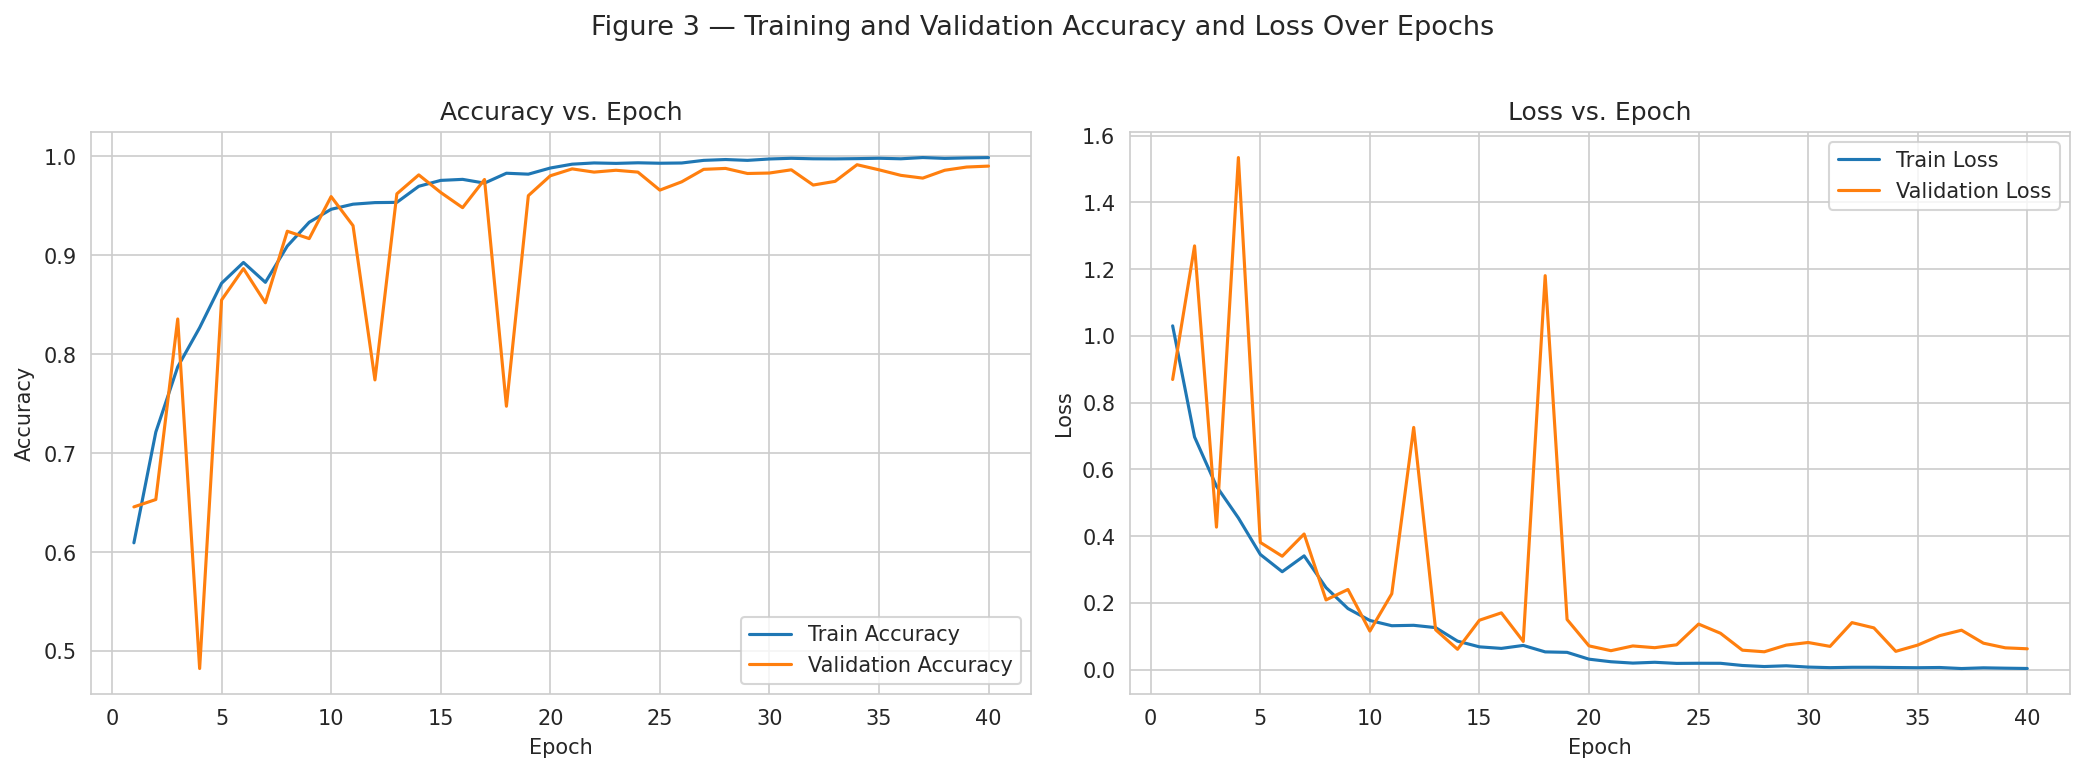

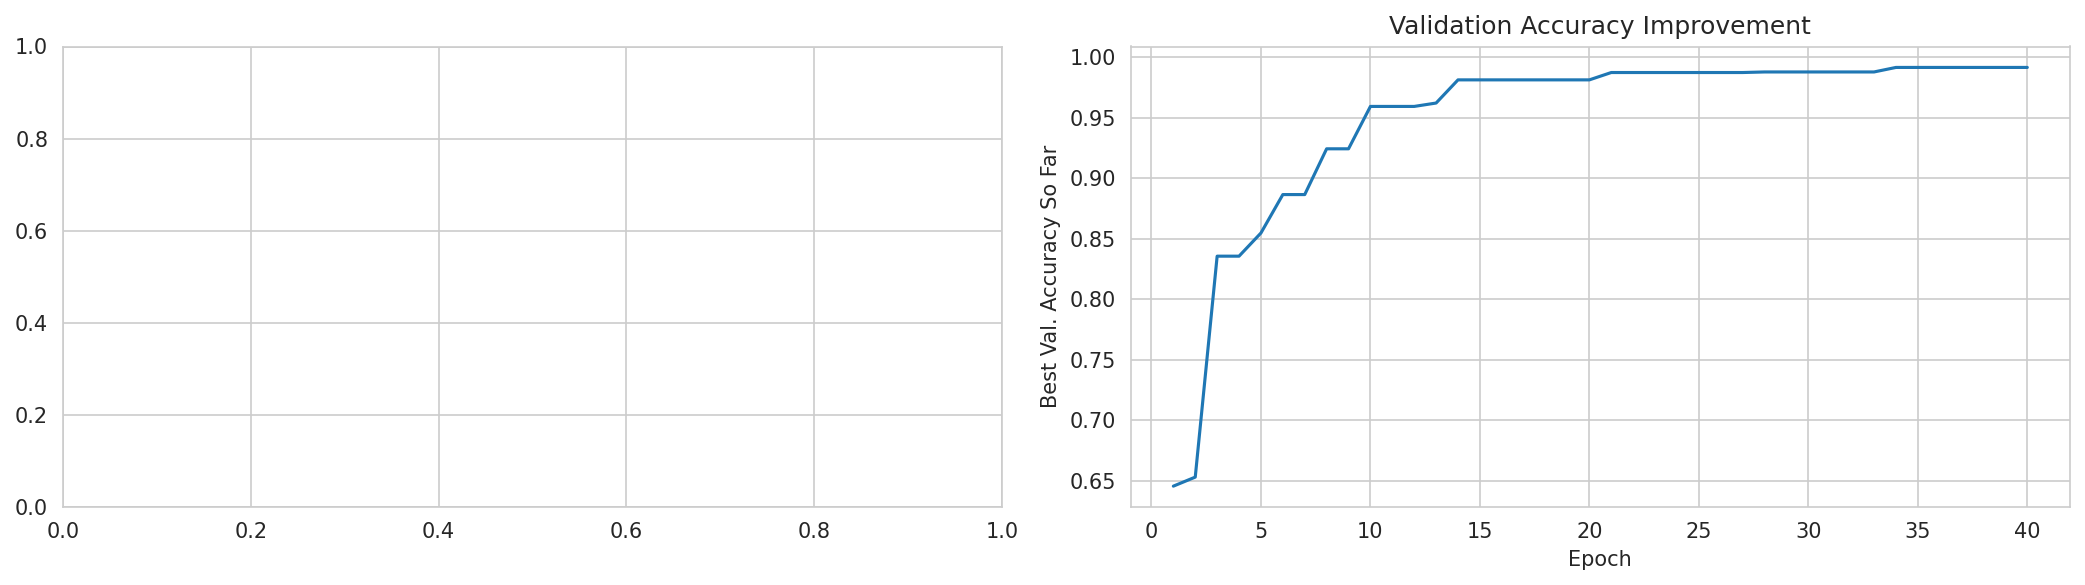


TABLE 4 — Stratified 5-Fold Cross-Validation Results
  Metric                    K-Fold   K    Mean       Std. Dev.
  Validation Accuracy       5-Fold   5    0.9613    0.0074
  Macro-F1                  5-Fold   5    0.9612    0.0075

TABLE 5 — Comparison With Standard CNN Backbones
         model   params  test_loss  test_acc  macro_f1  weighted_f1 wall_time_min
Proposed C-CNN 13270596   0.104665  0.979230  0.979379     0.979151           N/A
         VGG16 14847044   0.223265  0.956296  0.957348     0.956443          9.79
      ResNet50 24113284   0.142861  0.972306  0.972389     0.972241          7.78
   MobileNetV2  2586948   0.420205  0.930333  0.931592     0.931129          4.13


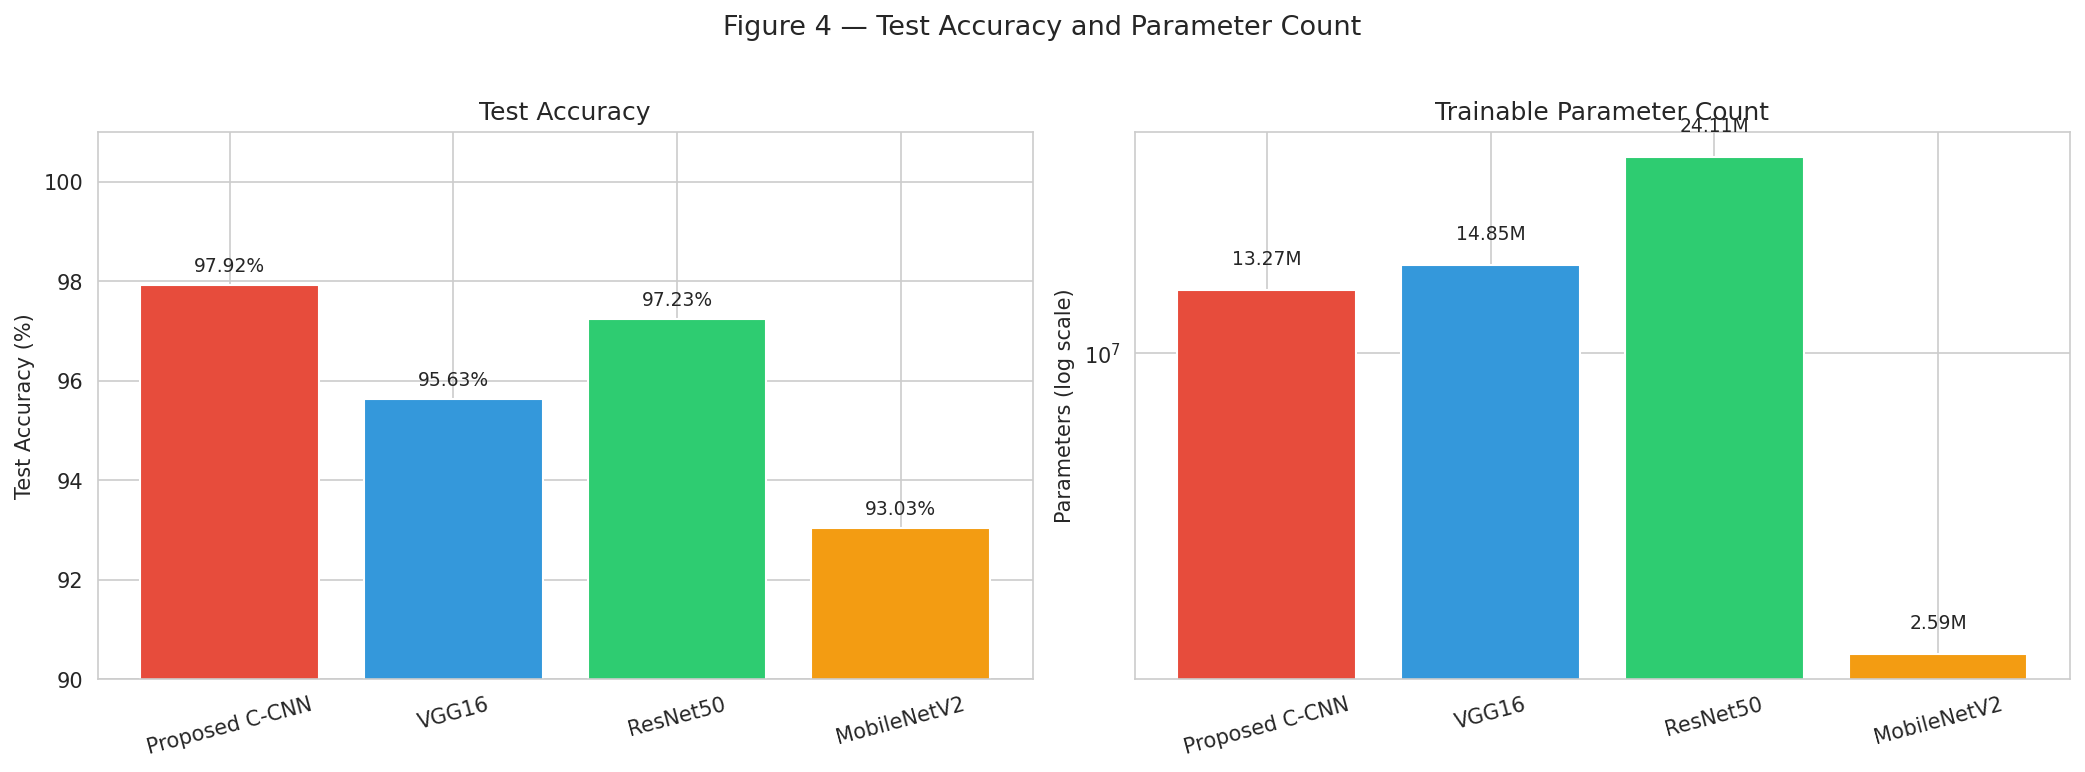

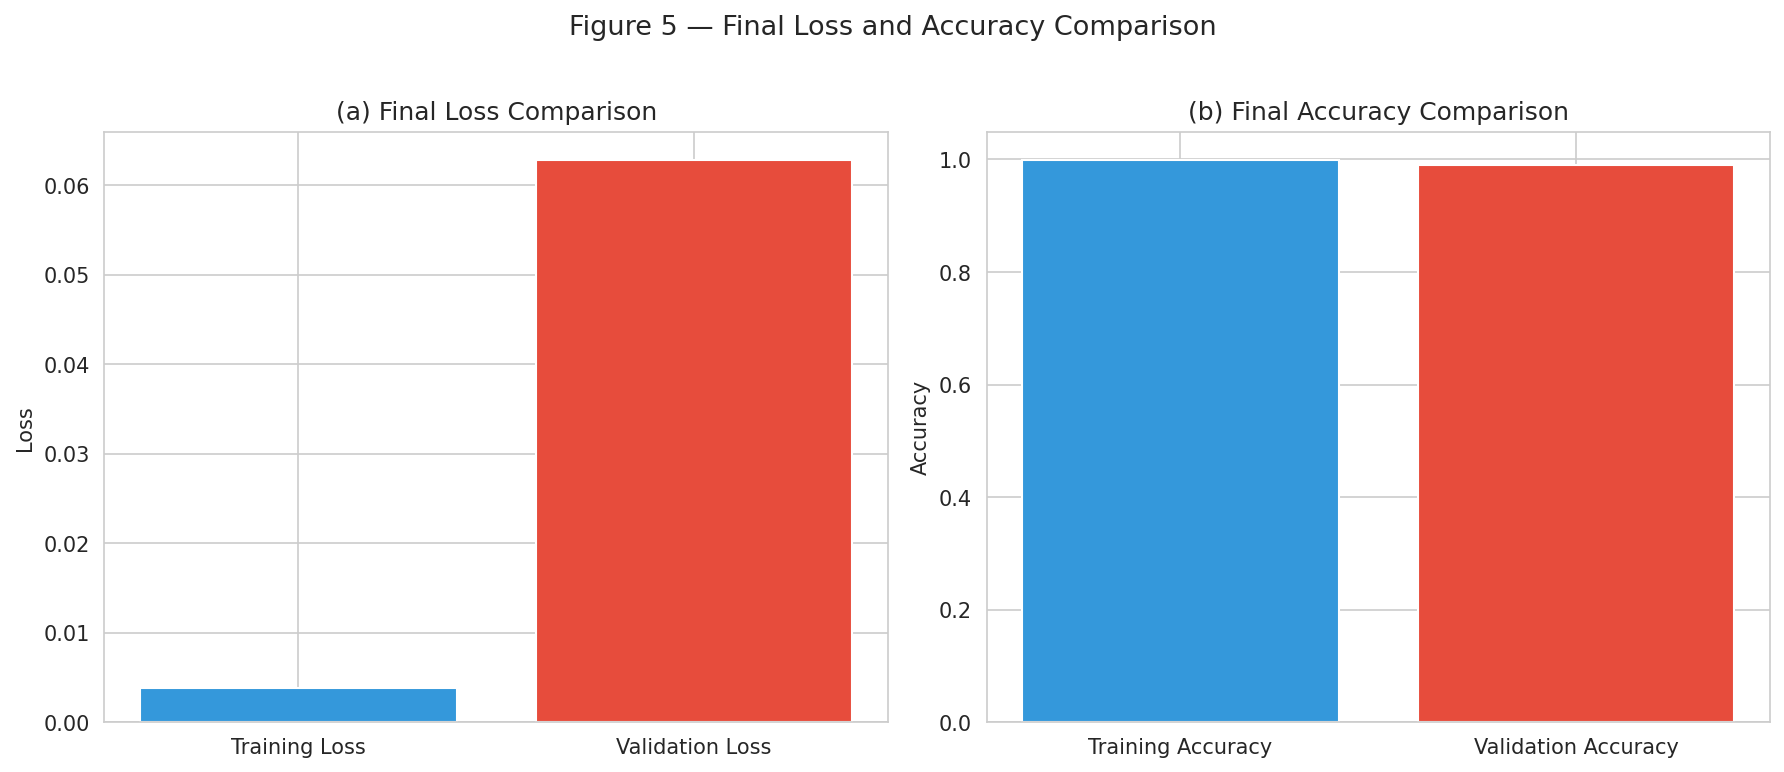

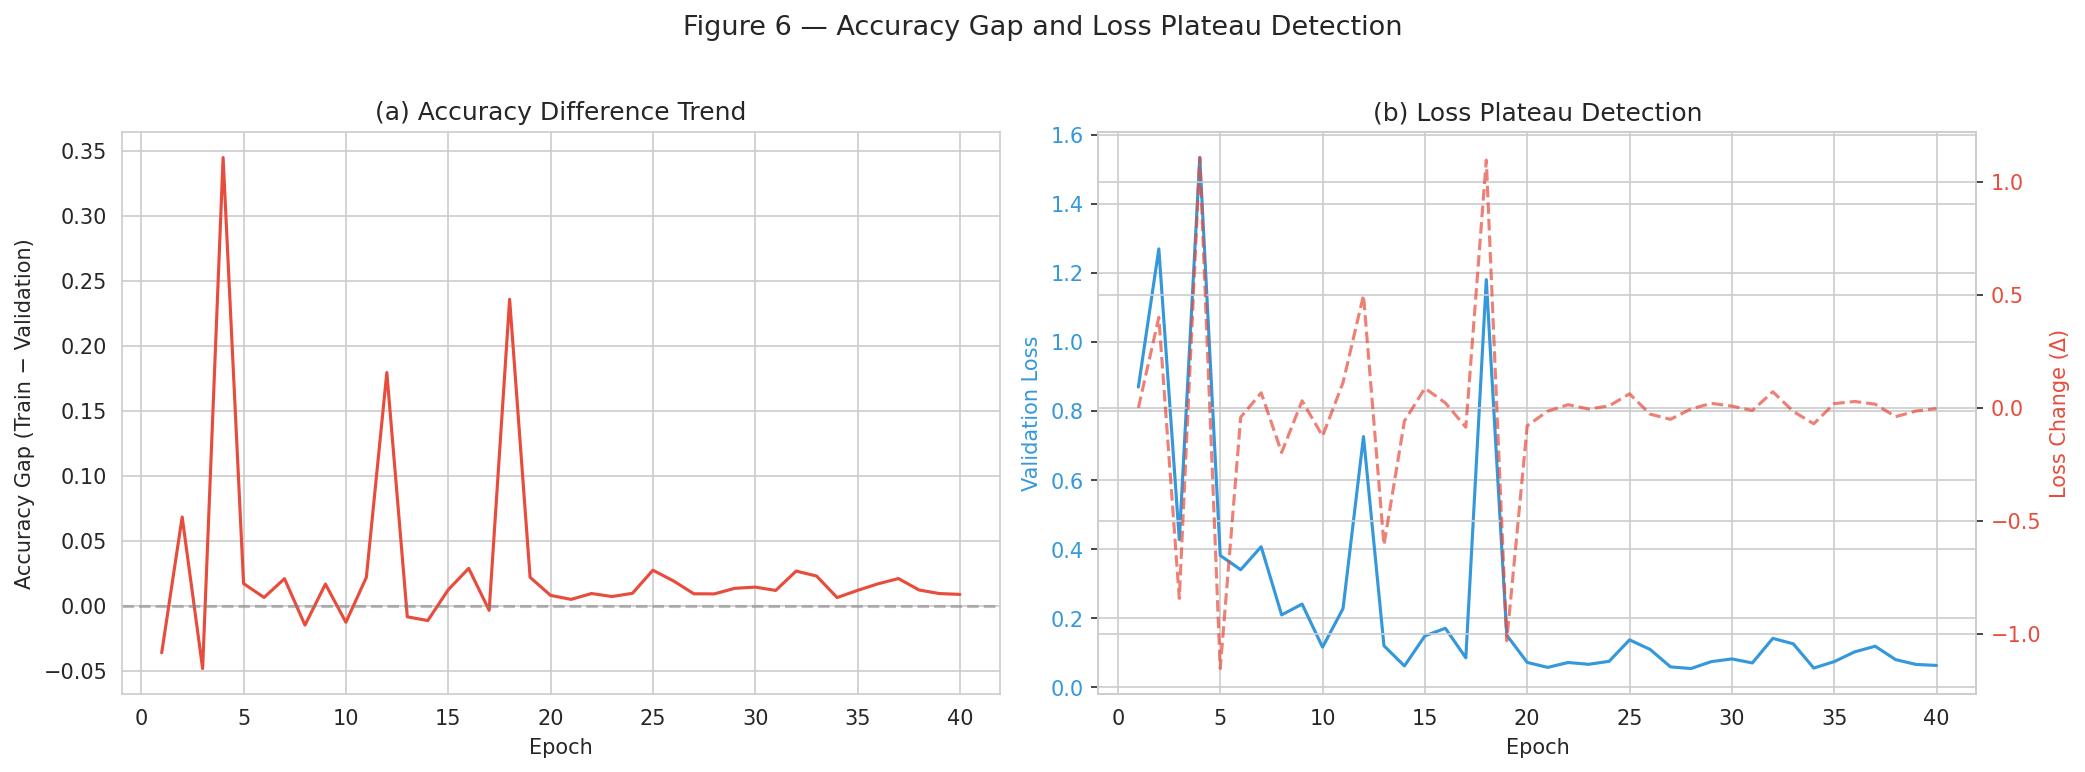


TABLE 6 — Classification Report
  Normal_no tumor       Prec: 0.9645  Rec: 0.9982  F1: 0.9811
  glioma                Prec: 0.9855  Rec: 0.9838  F1: 0.9846
  meningioma            Prec: 0.9797  Rec: 0.9477  F1: 0.9635
  pituitary             Prec: 0.9867  Rec: 0.9900  F1: 0.9884
  Overall Accuracy      0.9792

TABLE 7 — Dataset Composition
          Class  Train%  Val.%  Test%  Total%
Normal_no tumor    25.0  24.79  23.58   24.85
         glioma    25.0  23.06  23.97   24.73
     meningioma    25.0  24.93  26.48   25.13
      pituitary    25.0  27.22  25.96   25.29


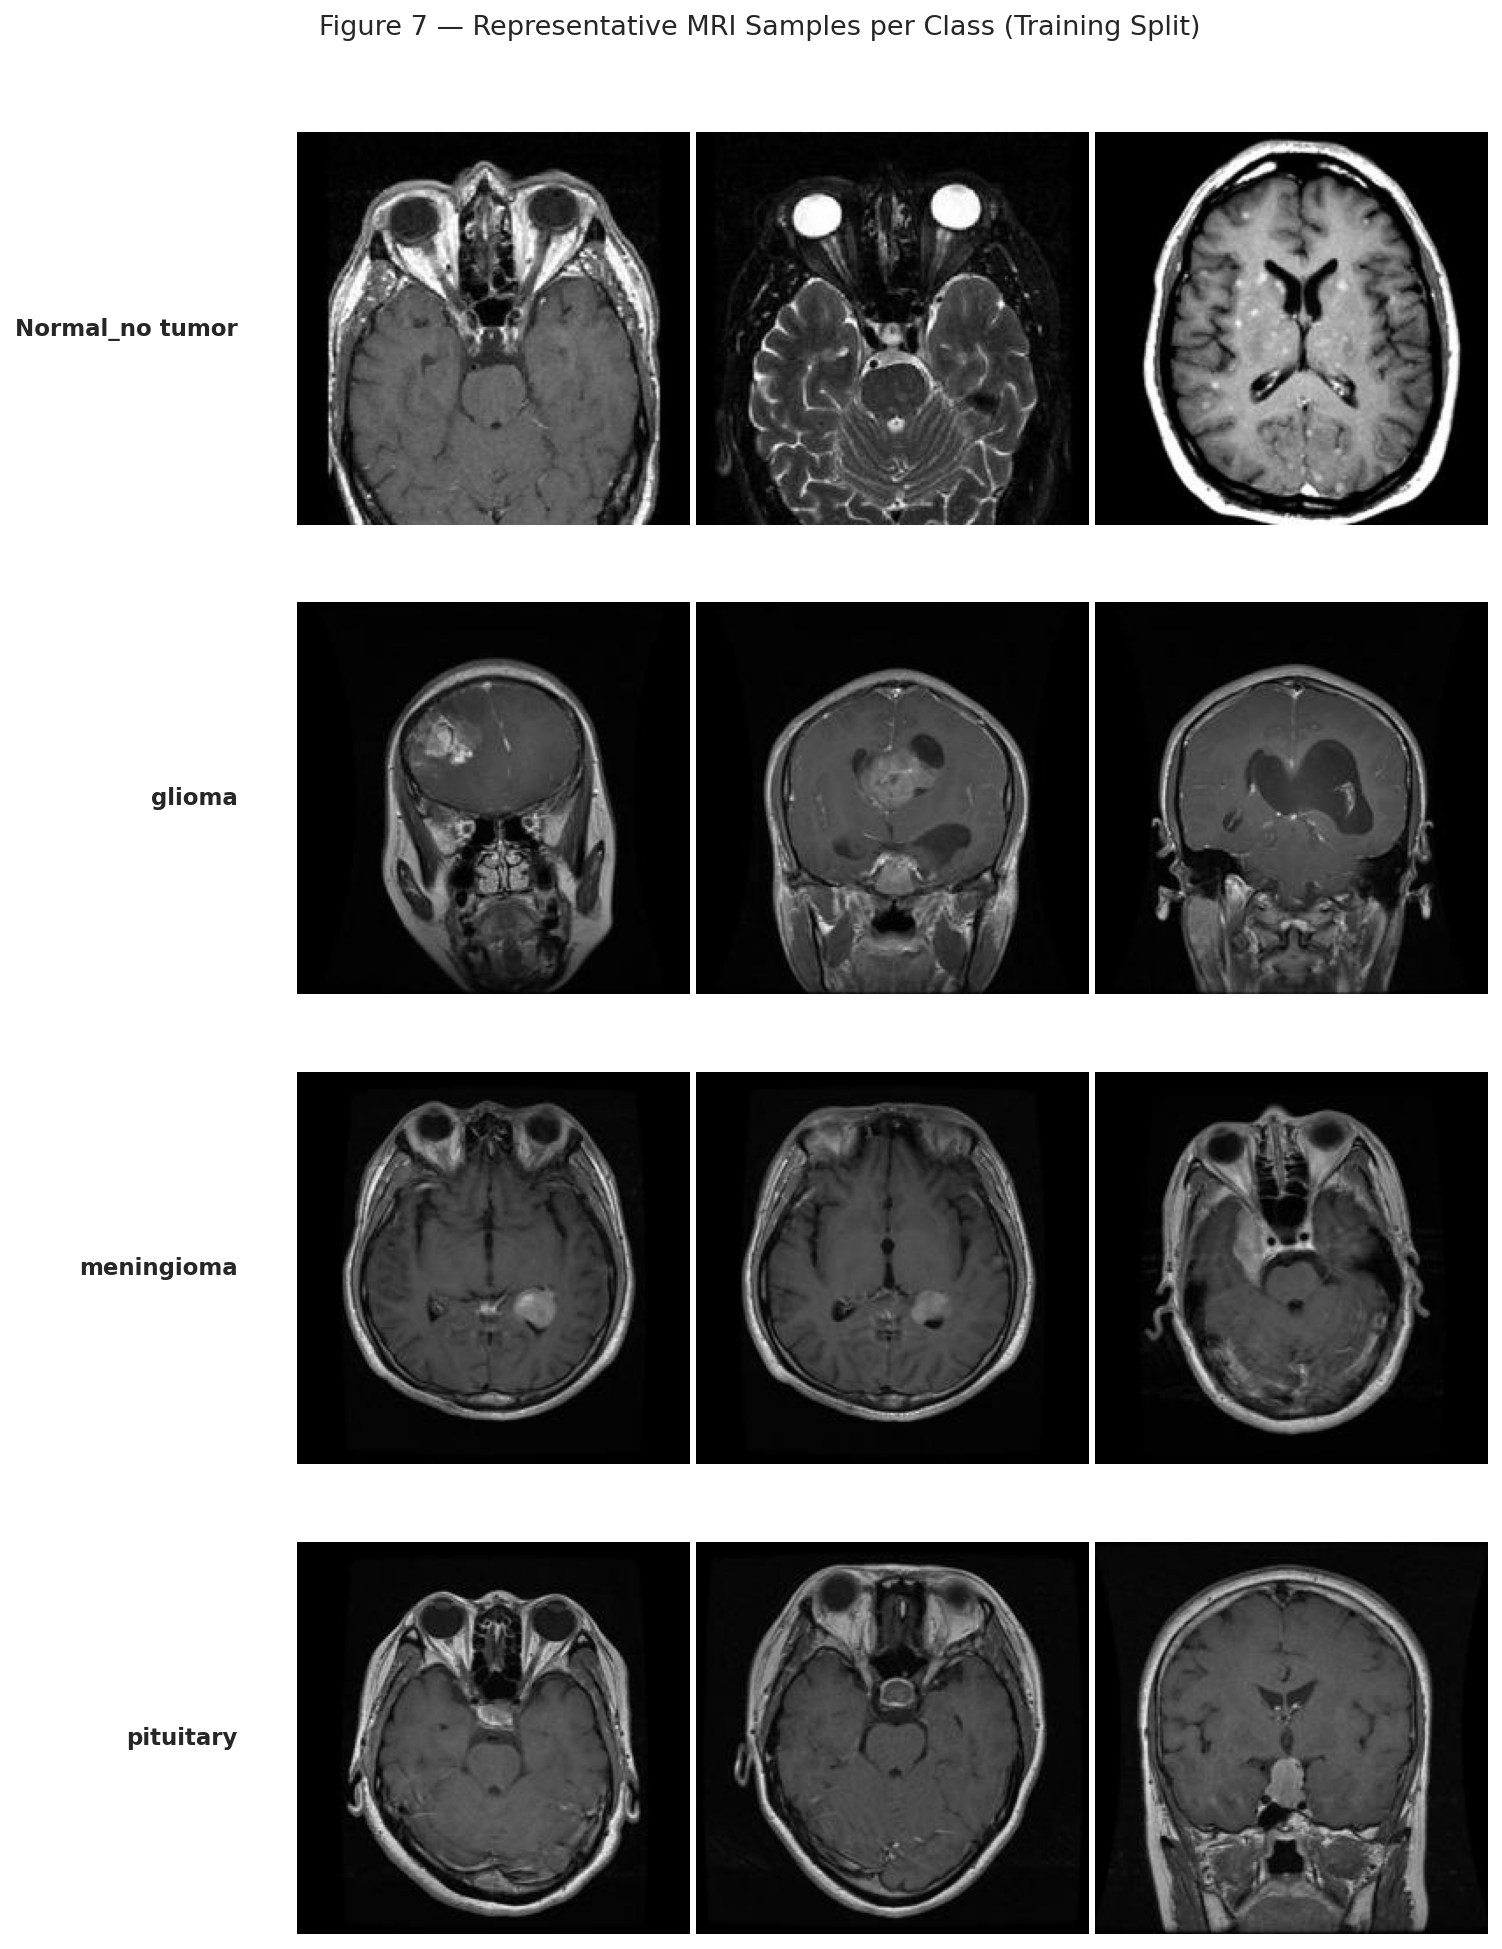

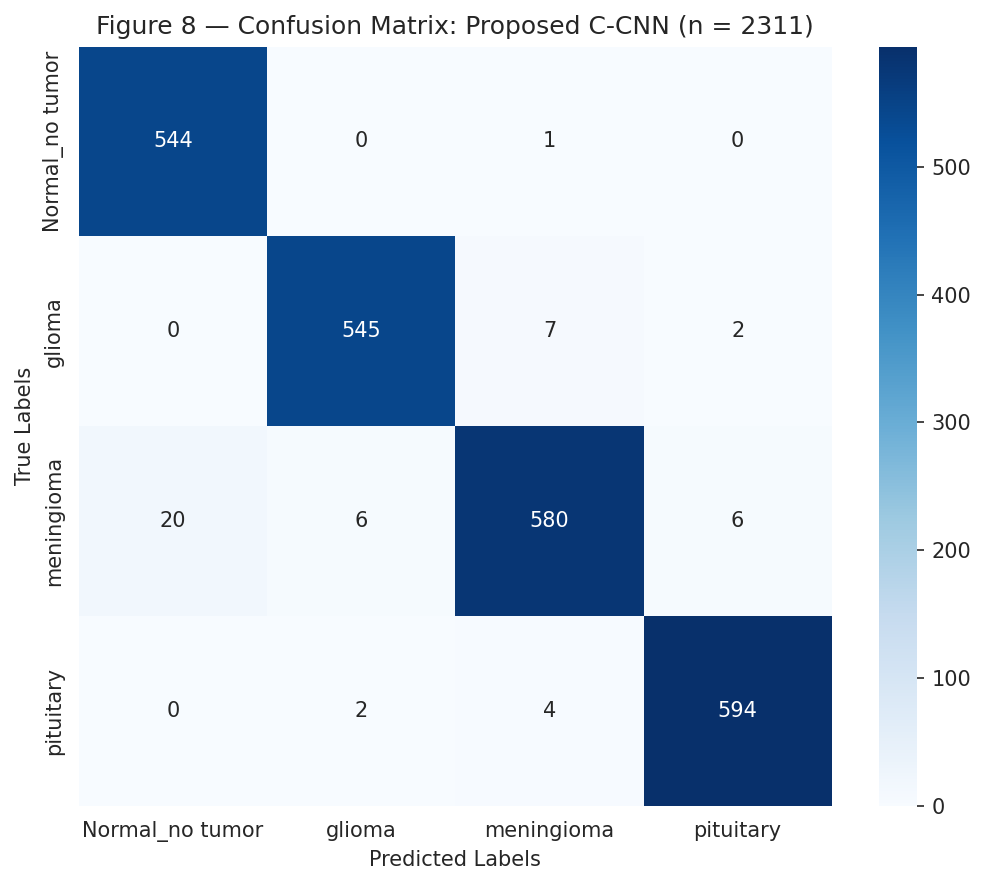

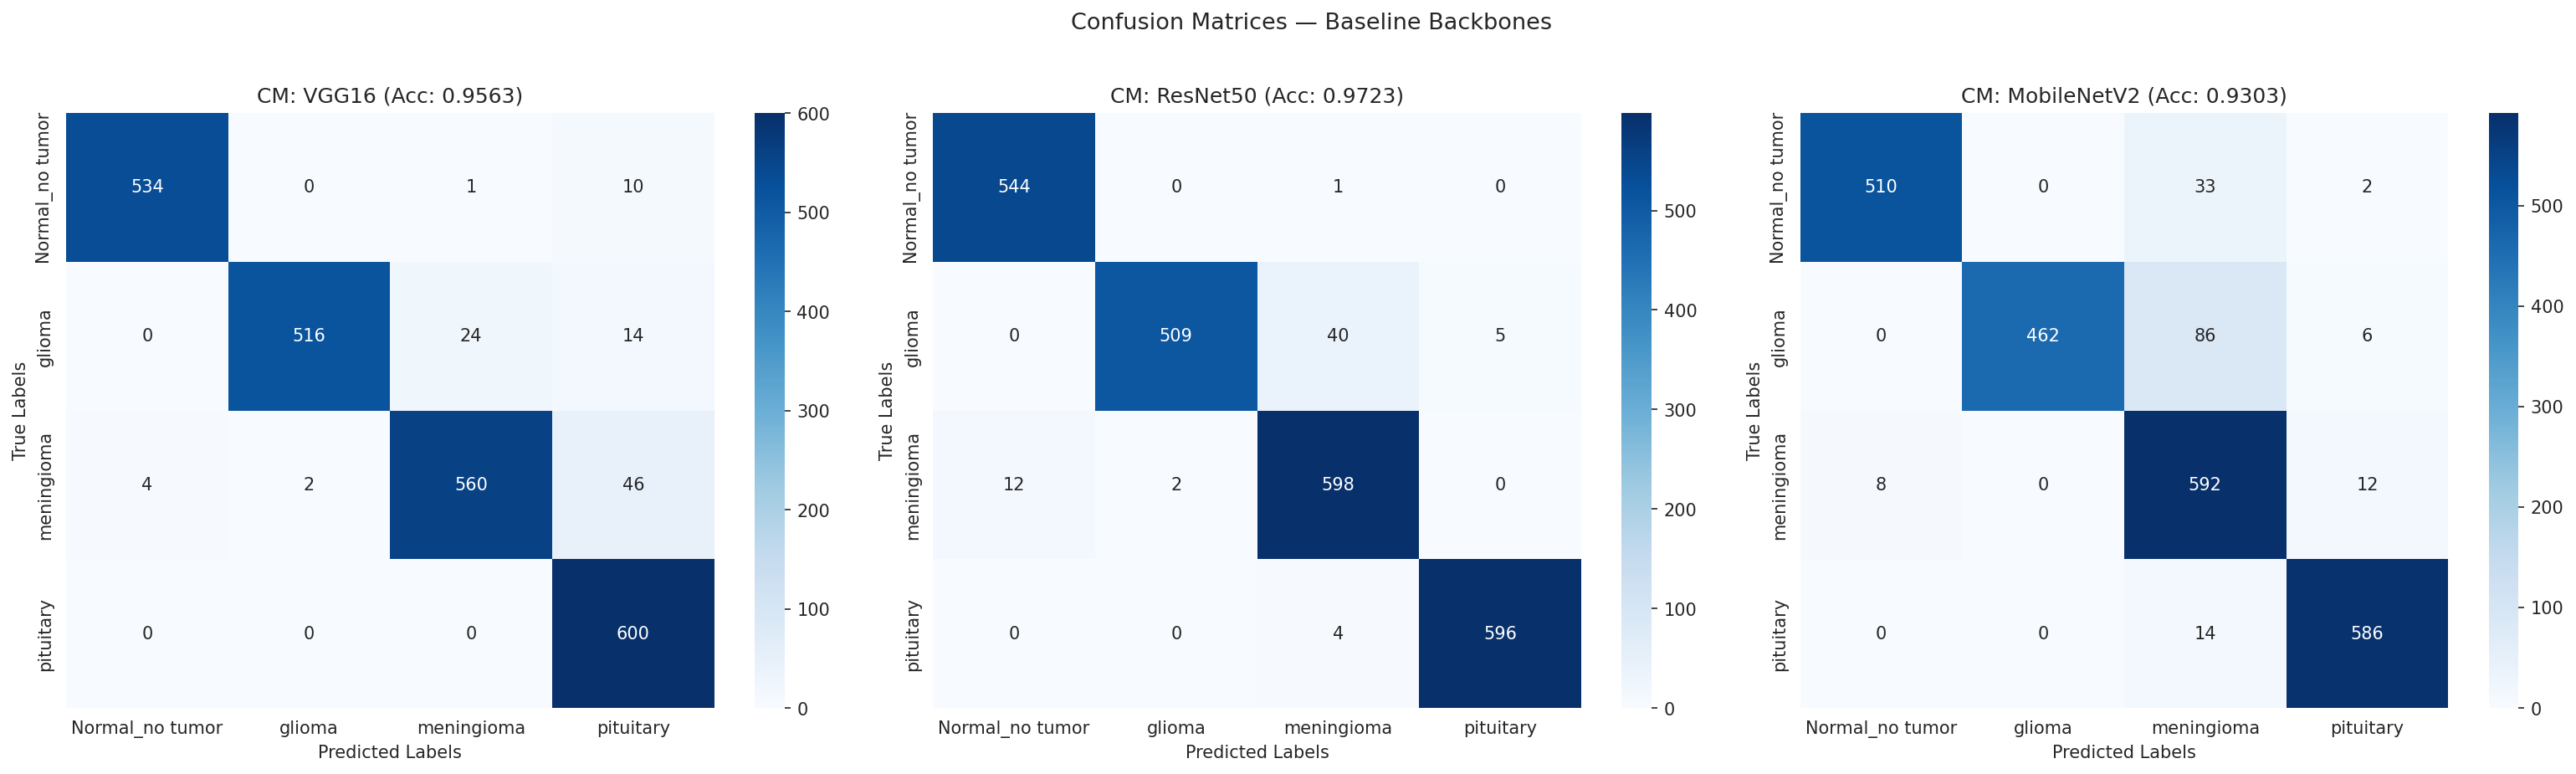

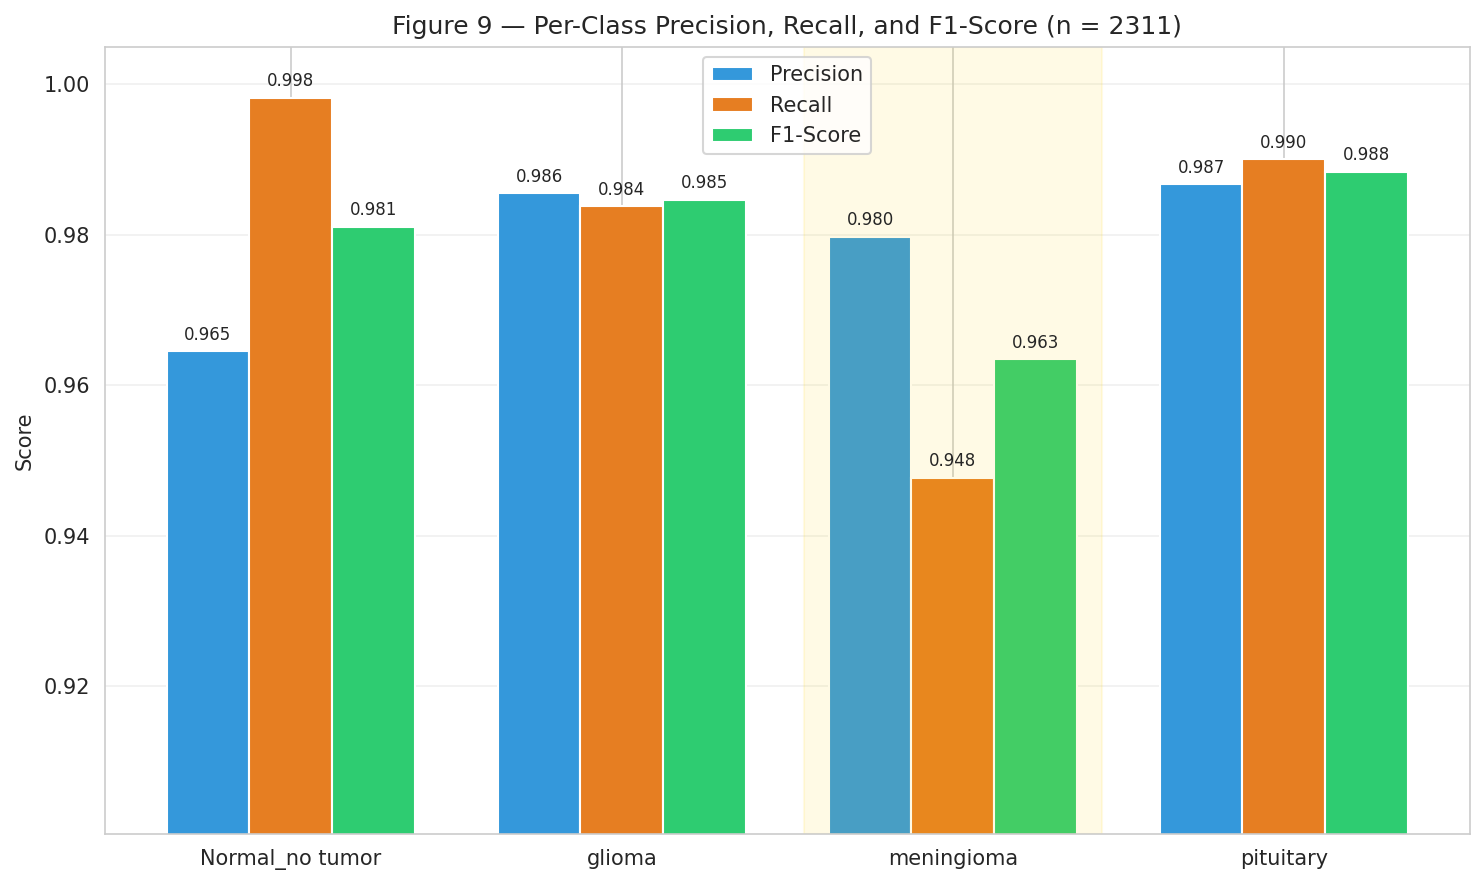

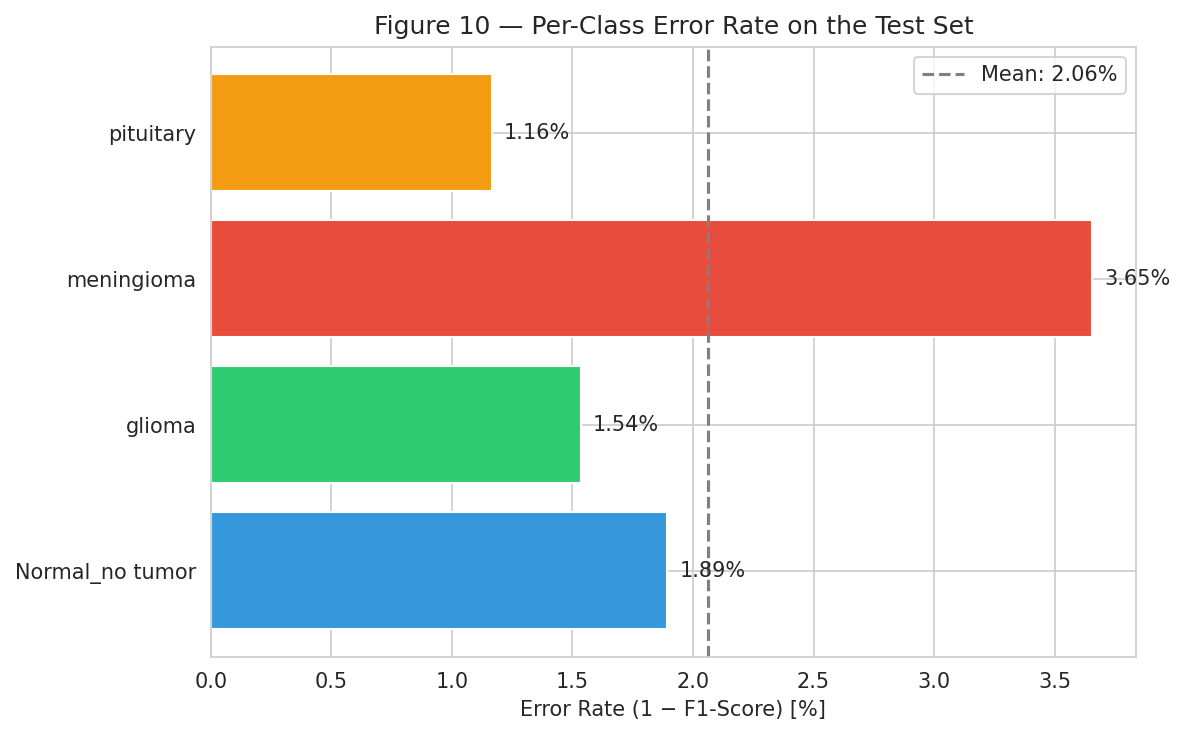

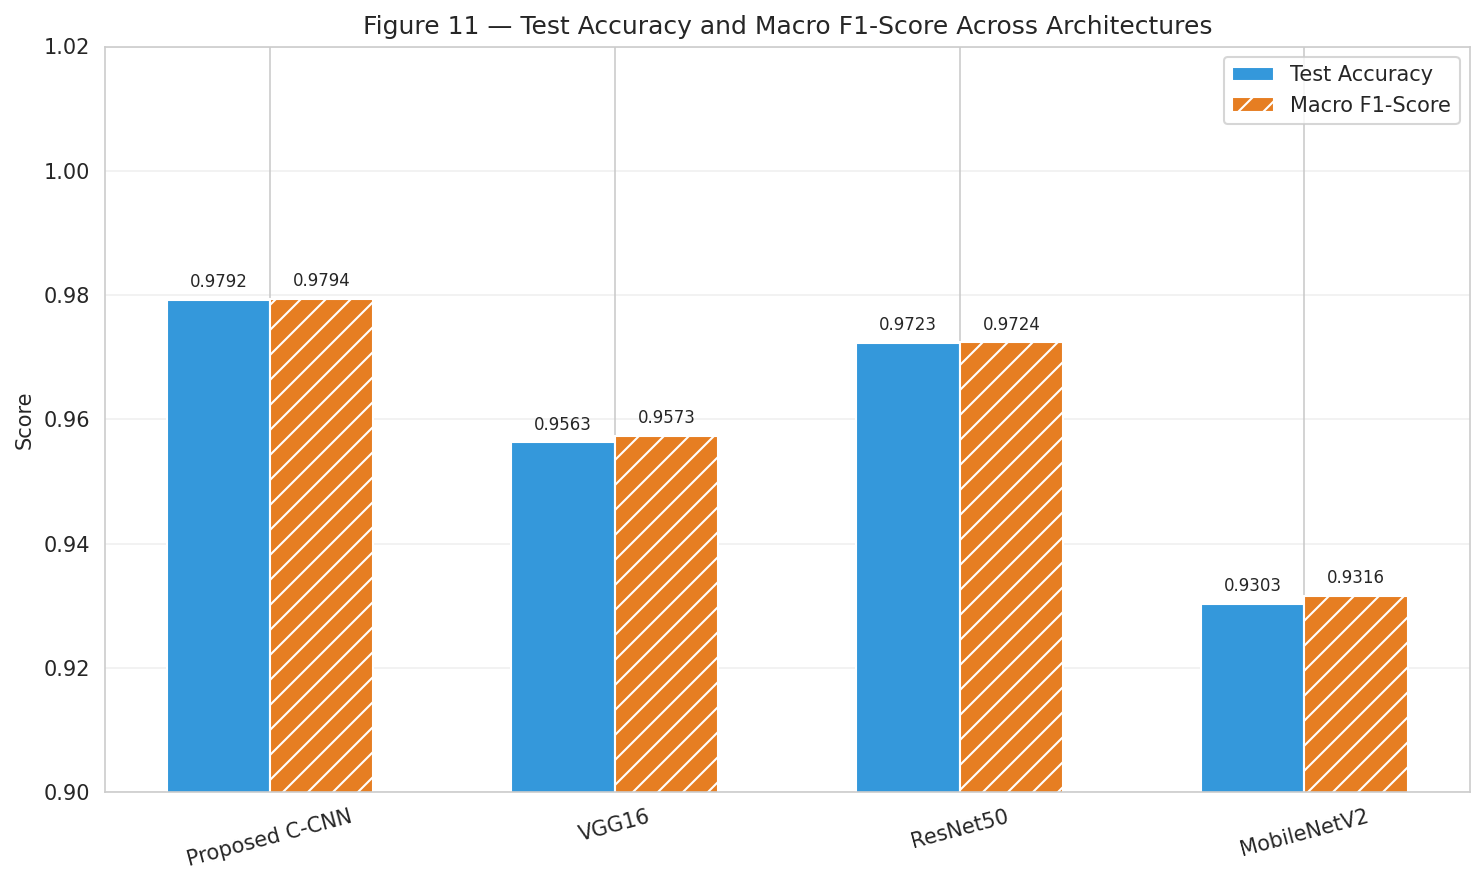

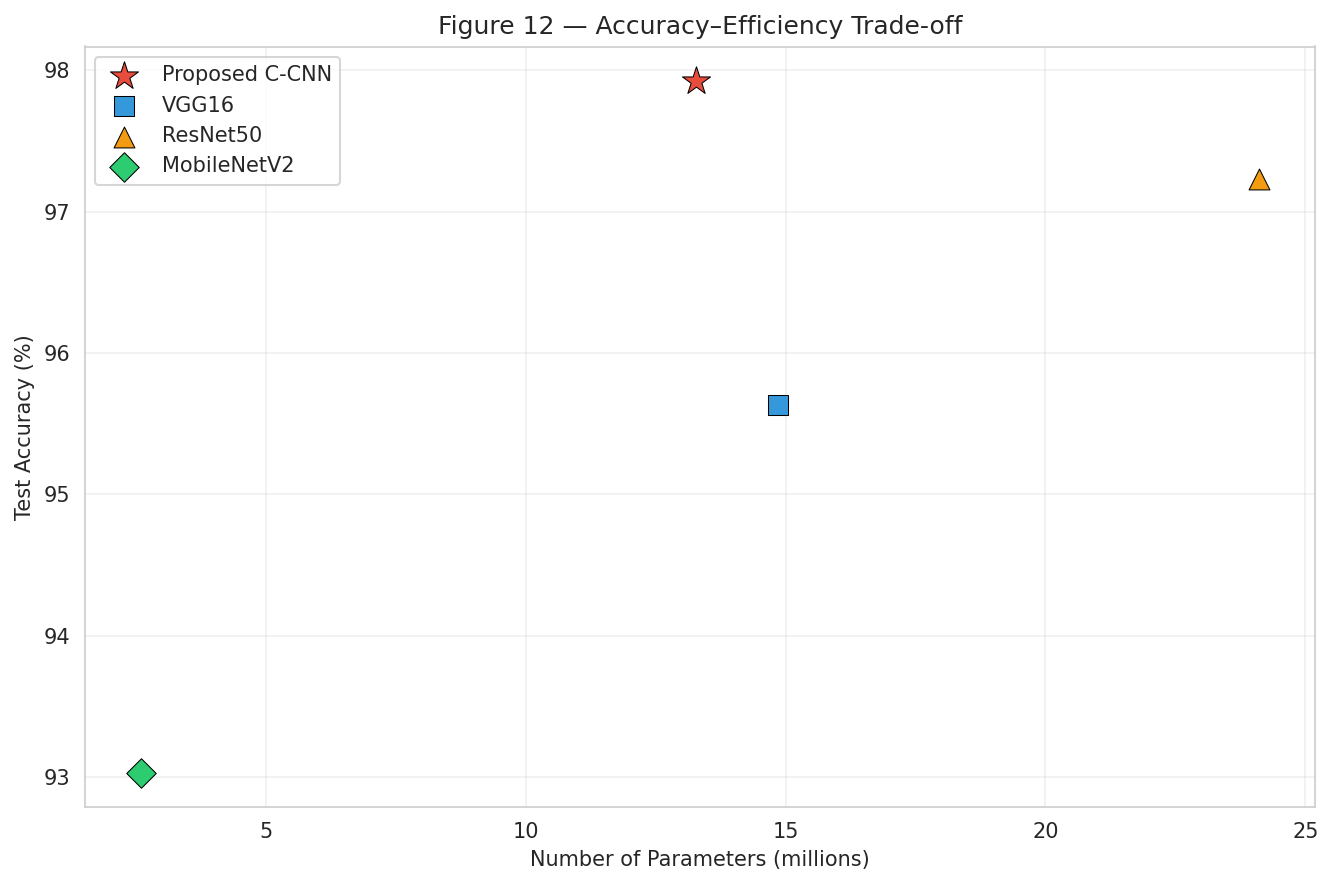


TABLE 8 — Computational Footprint and Inference Profiling
  Input resolution                                 224 x 224 x 3
  Trainable parameters (total)                     13,270,596
  Checkpoint size (MB)                             151.96
  FLOPs per forward pass (batch=1)                 1,511,775,448
  GFLOPs per forward pass (batch=1)                1.512
  GPU available                                    True
  GPU name                                         /physical_device:GPU:0
  Inference latency GPU (ms/img) batch=1           25.721
  Throughput GPU (img/s) batch=1                   38.88
  Inference latency GPU (ms/img) batch=32          0.787
  Throughput GPU (img/s) batch=32                  1270.54
  Inference latency CPU (ms/img) batch=1           52.470
  Throughput CPU (img/s) batch=1                   19.06
  GPU peak memory during profiling (MB)            5747.03
  GPU current memory after profiling (MB)          1678.50

ALL FIGURES AND TABLES GENERATED SUCCES

In [ ]:
# ============================================================
#  MASTER OUTPUT CELL — all figures and tables for the paper
# ============================================================
# This cell is self-contained: it reloads the C-CNN model and
# re-evaluates, so it works even after K.clear_session().
# Backbone predictions come from all_results (cell 9).
# ============================================================

import gc, json

# ---- Reload model from best checkpoint ----
print("Reloading best C-CNN checkpoint ...")
model = tf.keras.models.load_model(CKPT_PATH)
print(f"Model loaded — {model.count_params():,} parameters.")

# ---- Rebuild test dataset ----
test_data = build_dataset(TEST_DIR, training=False)

# ---- Re-evaluate on the test set ----
test_loss, test_acc = model.evaluate(test_data, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_data], axis=0)
y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)

report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)
macro_f1    = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy: {test_acc:.6f}")
print(f"Macro-F1:      {macro_f1:.6f}")

# ---- Retrieve training history ----
h = history.history

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300,
                      'font.size': 10})
epochs_ran = range(1, len(h['accuracy']) + 1)

# ====================== TABLE 3 ==========================
print("=" * 70)
print("TABLE 3 — Training Configuration of the Proposed C-CNN Model")
print("=" * 70)
config_items = [
    ('Image Size',           '224 x 224 pixels'),
    ('Batch Size',           str(BATCH_SIZE)),
    ('Epochs',               f'{EPOCHS} max, with early stopping'),
    ('Early Stopping',       'Monitor val_loss, patience 8, min_delta 1e-3, restore best weights'),
    ('Learning Rate Strategy','ReduceLROnPlateau on val_loss, factor 0.5, patience 5, min LR 1e-6'),
    ('Initial Learning Rate', str(INIT_LR)),
    ('Loss Function',        'Sparse categorical cross-entropy'),
    ('Optimizer',            'Adam'),
    ('Regularisation',       'Dropout layers in conv. and dense blocks'),
    ('Data Augmentation',    'RandomFlip (horizontal), RandomZoom, RandomContrast; training only'),
    ('Model Saving',         'ModelCheckpoint, best val. accuracy'),
]
for aspect, detail in config_items:
    print(f"  {aspect:28s} {detail}")

# ====================== FIGURE 3 =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_ran, h['accuracy'],     label='Train Accuracy')
axes[0].plot(epochs_ran, h['val_accuracy'],  label='Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs. Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_ran, h['loss'],     label='Train Loss')
axes[1].plot(epochs_ran, h['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs. Epoch')
axes[1].legend(); axes[1].grid(True)

fig.suptitle('Figure 3 — Training and Validation Accuracy and Loss Over Epochs',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig3_accuracy_loss.png', bbox_inches='tight')
plt.show()

# ---- Additional subplots for Figure 3: LR schedule, val-acc improvement ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if 'lr' in h:
    axes[0].plot(epochs_ran, h['lr'])
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Learning Rate')
    axes[0].set_title('Learning Rate vs. Epoch')
    axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    axes[0].grid(True)

best_so_far = np.maximum.accumulate(h['val_accuracy'])
axes[1].plot(epochs_ran, best_so_far)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Best Val. Accuracy So Far')
axes[1].set_title('Validation Accuracy Improvement')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('fig3_lr_improvement.png', bbox_inches='tight')
plt.show()

# ====================== TABLE 4 ==========================
print("\n" + "=" * 70)
print("TABLE 4 — Stratified 5-Fold Cross-Validation Results")
print("=" * 70)
print(f"  {'Metric':<25s} {'K-Fold':<8s} {'K':<4s} {'Mean':<10s} {'Std. Dev.'}")
print(f"  {'Validation Accuracy':<25s} {'5-Fold':<8s} {'5':<4s} {np.mean(cv_accuracies):.4f}    {np.std(cv_accuracies):.4f}")
print(f"  {'Macro-F1':<25s} {'5-Fold':<8s} {'5':<4s} {np.mean(cv_f1s):.4f}    {np.std(cv_f1s):.4f}")

# ====================== TABLE 5 ==========================
print("\n" + "=" * 70)
print("TABLE 5 — Comparison With Standard CNN Backbones")
print("=" * 70)
print_cols = ['model','params','test_loss','test_acc','macro_f1','weighted_f1','wall_time_min']
df_t5 = pd.DataFrame([{k: r[k] for k in print_cols} for r in all_results])
print(df_t5.to_string(index=False))

# ====================== FIGURE 4 =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = [r['model'] for r in all_results]
test_accs   = [r['test_acc'] * 100 for r in all_results]
param_counts = [r['params'] for r in all_results]

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

bars1 = axes[0].bar(model_names, test_accs, color=colors)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
for bar, val in zip(bars1, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(90, 101)
axes[0].tick_params(axis='x', rotation=15)

bars2 = axes[1].bar(model_names, param_counts, color=colors)
axes[1].set_ylabel('Parameters (log scale)')
axes[1].set_title('Trainable Parameter Count')
axes[1].set_yscale('log')
for bar, val in zip(bars2, param_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Figure 4 — Test Accuracy and Parameter Count', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig4_accuracy_params.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 5 =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

final_train_loss = h['loss'][-1]
final_val_loss   = h['val_loss'][-1]
axes[0].bar(['Training Loss', 'Validation Loss'],
            [final_train_loss, final_val_loss],
            color=['#3498DB', '#E74C3C'])
axes[0].set_title('(a) Final Loss Comparison')
axes[0].set_ylabel('Loss')

final_train_acc = h['accuracy'][-1]
final_val_acc   = h['val_accuracy'][-1]
axes[1].bar(['Training Accuracy', 'Validation Accuracy'],
            [final_train_acc, final_val_acc],
            color=['#3498DB', '#E74C3C'])
axes[1].set_title('(b) Final Accuracy Comparison')
axes[1].set_ylabel('Accuracy')

fig.suptitle('Figure 5 — Final Loss and Accuracy Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5_final_comparison.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 6 =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_gap = np.array(h['accuracy']) - np.array(h['val_accuracy'])
axes[0].plot(epochs_ran, acc_gap, color='#E74C3C', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy Gap (Train − Validation)')
axes[0].set_title('(a) Accuracy Difference Trend')
axes[0].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
axes[0].grid(True)

val_loss_arr = np.array(h['val_loss'])
loss_change  = np.diff(val_loss_arr, prepend=val_loss_arr[0])

ax2 = axes[1]
ax2.plot(epochs_ran, val_loss_arr, label='Validation Loss', color='#3498DB')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss', color='#3498DB')
ax2.tick_params(axis='y', labelcolor='#3498DB')

ax2b = ax2.twinx()
ax2b.plot(epochs_ran, loss_change, label='Loss Change (Δ)',
          color='#E74C3C', linestyle='--', alpha=0.7)
ax2b.set_ylabel('Loss Change (Δ)', color='#E74C3C')
ax2b.tick_params(axis='y', labelcolor='#E74C3C')
ax2.set_title('(b) Loss Plateau Detection')
ax2.grid(True)

fig.suptitle('Figure 6 — Accuracy Gap and Loss Plateau Detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig6_gap_plateau.png', bbox_inches='tight')
plt.show()

# ====================== TABLE 6 ==========================
print("\n" + "=" * 70)
print("TABLE 6 — Classification Report")
print("=" * 70)
for c in class_names:
    row = report[c]
    print(f"  {c:<20s}  Prec: {row['precision']:.4f}  "
          f"Rec: {row['recall']:.4f}  F1: {row['f1-score']:.4f}")
print(f"  {'Overall Accuracy':<20s}  {test_acc:.4f}")

# ====================== TABLE 7 ==========================
print("\n" + "=" * 70)
print("TABLE 7 — Dataset Composition")
print("=" * 70)
print(df_table7.to_string(index=False))

# ====================== FIGURE 7 =========================
# Paper layout: 4 rows (one per class) x 3 sample columns
N_SAMPLES = 3
fig, axes = plt.subplots(len(class_names), N_SAMPLES, figsize=(10, 13))
fig.suptitle('Figure 7 — Representative MRI Samples per Class (Training Split)',
             fontsize=13, y=1.01)
for row, c in enumerate(class_names):
    class_dir = os.path.join(TRAIN_DIR, c)
    sample_files = sorted(os.listdir(class_dir))[:N_SAMPLES]
    for col, fname in enumerate(sample_files):
        img = plt.imread(os.path.join(class_dir, fname))
        axes[row, col].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(c, fontsize=11, rotation=90, labelpad=10)
            axes[row, col].yaxis.set_visible(True)
            axes[row, col].tick_params(left=False, labelleft=False)
    # Add class label on the left using text
    axes[row, 0].text(-0.15, 0.5, c, transform=axes[row, 0].transAxes,
                       fontsize=11, fontweight='bold', va='center', ha='right')
plt.tight_layout()
plt.savefig('fig7_samples.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 8 =========================
# Confusion matrix for the proposed C-CNN
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title(f'Figure 8 — Confusion Matrix: Proposed C-CNN (n = {len(y_true)})')
plt.tight_layout()
plt.savefig('fig8_confusion_matrix.png', bbox_inches='tight')
plt.show()

# ---- Confusion matrices for all backbone models ----
backbone_cms = [r for r in all_results if r['model'] != 'Proposed C-CNN'
                and 'y_true' in r and 'y_pred' in r]

if backbone_cms:
    n_backs = len(backbone_cms)
    fig, axes = plt.subplots(1, n_backs, figsize=(7 * n_backs, 6))
    if n_backs == 1:
        axes = [axes]
    for i, r in enumerate(backbone_cms):
        cm_b = confusion_matrix(r['y_true'], r['y_pred'])
        sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=axes[i])
        axes[i].set_xlabel('Predicted Labels')
        axes[i].set_ylabel('True Labels')
        axes[i].set_title(f"CM: {r['model']} (Acc: {r['test_acc']:.4f})")
    fig.suptitle('Confusion Matrices — Baseline Backbones', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('fig8b_backbone_confusion_matrices.png', bbox_inches='tight')
    plt.show()
else:
    print("  (Backbone predictions not available — re-run cell 9 to generate CMs)")

# ====================== FIGURE 9 =========================
prec_vals  = [report[c]['precision'] for c in class_names]
rec_vals   = [report[c]['recall']    for c in class_names]
f1_vals    = [report[c]['f1-score']  for c in class_names]

x = np.arange(len(class_names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars_p = ax.bar(x - w, prec_vals, w, label='Precision', color='#3498DB')
bars_r = ax.bar(x,     rec_vals,  w, label='Recall',    color='#E67E22')
bars_f = ax.bar(x + w, f1_vals,   w, label='F1-Score',  color='#2ECC71')

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

men_idx = class_names.index('meningioma') if 'meningioma' in class_names else None
if men_idx is not None:
    ax.axvspan(men_idx - 0.45, men_idx + 0.45, alpha=0.1, color='gold')

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Score')
ax.set_title(f'Figure 9 — Per-Class Precision, Recall, and F1-Score (n = {len(y_true)})')
ax.legend()
ax.set_ylim(0.95 * min(prec_vals + rec_vals + f1_vals), 1.005)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_per_class_metrics.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 10 ========================
error_rates = [(1 - f) * 100 for f in f1_vals]
mean_error  = np.mean(error_rates)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(class_names, error_rates, color=['#3498DB', '#2ECC71', '#E74C3C', '#F39C12'])
ax.axvline(x=mean_error, color='grey', linestyle='--', label=f'Mean: {mean_error:.2f}%')
for bar, val in zip(bars, error_rates):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)
ax.set_xlabel('Error Rate (1 − F1-Score) [%]')
ax.set_title('Figure 10 — Per-Class Error Rate on the Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_error_rate.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 11 ========================
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(all_results))
names_all  = [r['model'] for r in all_results]
accs_all   = [r['test_acc'] for r in all_results]
f1s_all    = [r['macro_f1'] for r in all_results]

ax.bar(x - 0.15, accs_all, 0.3, label='Test Accuracy', color='#3498DB')
ax.bar(x + 0.15, f1s_all,  0.3, label='Macro F1-Score', color='#E67E22',
       hatch='//', edgecolor='white')

for i in range(len(all_results)):
    ax.text(i - 0.15, accs_all[i] + 0.002, f'{accs_all[i]:.4f}',
            ha='center', fontsize=8)
    ax.text(i + 0.15, f1s_all[i] + 0.002, f'{f1s_all[i]:.4f}',
            ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names_all, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Figure 11 — Test Accuracy and Macro F1-Score Across Architectures')
ax.legend()
ax.set_ylim(0.90, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', bbox_inches='tight')
plt.show()

# ====================== FIGURE 12 ========================
fig, ax = plt.subplots(figsize=(9, 6))
markers  = ['*', 's', '^', 'D']
colors12 = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71']
sizes    = [200, 100, 100, 100]

for i, r in enumerate(all_results):
    ax.scatter(r['params'] / 1e6, r['test_acc'] * 100,
               marker=markers[i], color=colors12[i], s=sizes[i],
               label=r['model'], zorder=5, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Number of Parameters (millions)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Figure 12 — Accuracy–Efficiency Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_tradeoff.png', bbox_inches='tight')
plt.show()

# ====================== TABLE 8 ==========================
print("\n" + "=" * 70)
print("TABLE 8 — Computational Footprint and Inference Profiling")
print("=" * 70)
for k, v in table8.items():
    print(f"  {k:48s} {v}")

# ============================================================
print("\n" + "=" * 70)
print("ALL FIGURES AND TABLES GENERATED SUCCESSFULLY")
print("=" * 70)
print("\nFigures saved as PNG files in the working directory.")
print("You can also find them displayed inline above.")

In [ ]:
# ============================================================
# Save all numerical results to a JSON file for reproducibility
# ============================================================
results_export = {
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'classification_report': {c: report[c] for c in class_names},
    'cross_validation': {
        'mean_accuracy': float(np.mean(cv_accuracies)),
        'std_accuracy': float(np.std(cv_accuracies)),
        'mean_f1': float(np.mean(cv_f1s)),
        'std_f1': float(np.std(cv_f1s)),
        'fold_accuracies': [float(a) for a in cv_accuracies],
        'fold_f1s': [float(f) for f in cv_f1s],
    },
    'backbone_comparison': all_results,
    'confusion_matrix': cm.tolist(),
    'dataset_composition': df_table7.to_dict(orient='records'),
    'computational_profile': table8,
    'training_history': {
        'accuracy': h['accuracy'],
        'val_accuracy': h['val_accuracy'],
        'loss': h['loss'],
        'val_loss': h['val_loss'],
    }
}

with open('results_full.json', 'w') as f:
    json.dump(results_export, f, indent=2, default=str)

print("All results saved to results_full.json")

All results saved to results_full.json


In [ ]:
# ============================================================
#  PAPER TABLE 4 , TABLE 5, TABLE 7, TABLE 8
# ============================================================

print("=" * 70)
print("TABLE 4 — Stratified 5-Fold Cross-Validation Results")
print("=" * 70)
print(f"{'Metric':<25s} {'K-Fold':<8s} {'K':<4s} {'Mean':<10s} {'Std. Dev.'}")
print(f"{'Validation Accuracy':<25s} {'5-Fold':<8s} {'5':<4s} {np.mean(cv_accuracies):.4f}    {np.std(cv_accuracies):.4f}")
print(f"{'Macro-F1':<25s} {'5-Fold':<8s} {'5':<4s} {np.mean(cv_f1s):.4f}    {np.std(cv_f1s):.4f}")

print("\n" + "=" * 70)
print("TABLE 5 — Comparison With Standard CNN Backbones")
print("=" * 70)
print(f"{'Model':<18s} {'Params':>12s} {'Test Loss':>10s} {'Test Acc':>10s} {'Macro-F1':>10s} {'W-F1':>10s} {'Time':>8s}")
for r in all_results:
    wt = r['wall_time_min'] if r['wall_time_min'] != 'N/A' else 'N/A'
    wt_str = f"{wt:.2f}" if isinstance(wt, (int, float)) else wt
    print(f"{r['model']:<18s} {r['params']:>12,d} {r['test_loss']:>10.6f} "
          f"{r['test_acc']:>10.6f} {r['macro_f1']:>10.6f} {r['weighted_f1']:>10.6f} {wt_str:>8s}")

print("\n" + "=" * 70)
print("TABLE 6 — Classification Report")
print("=" * 70)
print(f"{'Class':<20s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
for c in class_names:
    row = report[c]
    print(f"{c:<20s} {row['precision']:>10.4f} {row['recall']:>10.4f} {row['f1-score']:>10.4f}")
print(f"{'Overall Accuracy':<20s} {'':>10s} {'':>10s} {test_acc:>10.4f}")

print("\n" + "=" * 70)
print("TABLE 8 — Computational Footprint and Inference Profiling")
print("=" * 70)
for k, v in table8.items():
    print(f"  {k:48s} {v}")

print("\n" + "=" * 70)
print("DONE — Update these tables in the manuscript.")
print("=" * 70)

TABLE 4 — Stratified 5-Fold Cross-Validation Results
Metric                    K-Fold   K    Mean       Std. Dev.
Validation Accuracy       5-Fold   5    0.9613    0.0074
Macro-F1                  5-Fold   5    0.9612    0.0075

TABLE 5 — Comparison With Standard CNN Backbones
Model                    Params  Test Loss   Test Acc   Macro-F1       W-F1     Time
Proposed C-CNN       13,270,596   0.104665   0.979230   0.979379   0.979151      N/A
VGG16                14,847,044   0.223265   0.956296   0.957348   0.956443     9.79
ResNet50             24,113,284   0.142861   0.972306   0.972389   0.972241     7.78
MobileNetV2           2,586,948   0.420205   0.930333   0.931592   0.931129     4.13

TABLE 6 — Classification Report
Class                 Precision     Recall   F1-Score
Normal_no tumor          0.9645     0.9982     0.9811
glioma                   0.9855     0.9838     0.9846
meningioma               0.9797     0.9477     0.9635
pituitary                0.9867     0.9900     0